# Sliding-Window LZ77 Compression with Comma-Free Coding

This explanation details the bit-level sliding-window LZ77 algorithm implementation using comma-free codes. The algorithm is inspired by and directly follows the structure described in **Wyner and Ziv (1994)**: "The Sliding-Window Lempel-Ziv Algorithm is Asymptotically Optimal"

---

## Overview

This algorithm implements a variant of **LZ77 compression**, enhanced by:
- A **sliding window** mechanism to find matches,
- **Comma-free prefix codes** for self-delimiting length encoding,
- A **bitwise buffer** abstraction for I/O,
- Conditional compression based on **bit cost analysis**.

It approximates the entropy rate of a stationary ergodic source — the theoretical lower bound on compressibility — as described in [Wyner & Ziv, 1994, Section II].

---

## Step-by-Step Algorithm Explanation

### 1. **Initialization: Raw Window Encoding**

The first `n_w` symbols are emitted *without compression*. They form the **initial context window**, `Xⁿʷ`.

- This startup overhead uses `log₂(A)` bits per symbol, where `A` is the alphabet size.
- Matches the overhead described in [Section II, Wyner & Ziv], where initial symbols are stored uncompressed.

```python
out.append_raw(seq[:n_w])
```

---

### 2. **Main Loop: Phrase Search and Encoding**

At every step:
1. Search the window for the **longest matching prefix** with the current suffix.
2. Encode the match **length** using a comma-free prefix code.
3. Encode the **contents** of the phrase:
   - As raw symbols (if shorter),
   - Or as a **pointer** to the match position (if more efficient).

This mirrors:
> *“Let L₁ be the largest integer such that a copy of `Xₙʷ₊₁ : Xₙʷ₊ₗ` begins in the window”*  
> – [Wyner & Ziv, Equation (1)]

```python
if max_L * log2_alphabet < position_bits:
    out.append_raw(seq[i:i + max_L])
else:
    out.append_int(best_pos, num_bits=position_bits)
```

---

### 3. **Comma-Free Code for Phrase Lengths**

Phrase length `L` is encoded with a **comma-free prefix code**:
- A **unary prefix**: `0...01` of length `k-1` for a binary `k`-bit number,
- A **binary body**: the number `L` in `k` bits.

This matches the design in [Appendix, Wyner & Ziv (1994)]:
> *“The prefix d(l) encodes the length of b(L); the next bits encode L.”*

```python
def comma_free_encode(L):
    bL = bin(L)[2:]
    prefix = [0] * (len(bL) - 1) + [1]
    body = [int(b) for b in bL]
    return prefix + body
```

---

### 4. **Sliding Window Update**

After each phrase, the window is updated to include the new symbols while preserving its size:

```python
window = (window + phrase)[-n_w:]
```

This follows the behavior in [Section II], where:
> *“The new window is X_{nw + L}, and has length n_w.”*

---

## Decoding

The decoding process:
1. Reads the initial window raw.
2. Iteratively:
   - Decodes `L` using `comma_free_decode()`,
   - Determines whether raw or reference decoding applies,
   - Reconstructs the phrase and updates the window.

```python
if L * log2_alphabet < position_bits:
    phrase = buf.read_raw(L)
else:
    pos = buf.read_int(position_bits)
    phrase = window[pos:pos + L]
```

Matches this from the paper:
> *“With knowledge of the window, e(L), and S, the decoder can recover Y.”*

---

## Theoretical Justification and Optimality

The algorithm is justified by the following **core theorem** from [Wyner & Ziv, Theorem 2.1]:

$$\lim_{n_w \to \infty} \lim_{N \to \infty} R(N) = H$$

> where `R(N)` is the average bits per symbol and `H` is the entropy of the source.

This implementation ensures:
- **Prefix-freeness** via comma-free codes,
- **Efficiency** via greedy match selection,
- **Rate adaptivity** by choosing the shorter bit path (raw or pointer),
- **Stationary ergodic compatibility** (theoretical assumption in [Section I]).

Thus, it asymptotically achieves the **entropy rate of the source**, satisfying the optimality criteria.

---

## Summary

- Implements a **bit-precise version** of LZ77 using **comma-free codes**,
- Matches the formal structure and motivation in Wyner & Ziv’s 1994 IEEE paper,
- Provides a working model for theoretical exploration of **universal data compression**,
- Achieves **entropy-rate compression** in the limit.

> This implementation is a clean and pedagogically useful example of **constructive universal coding**


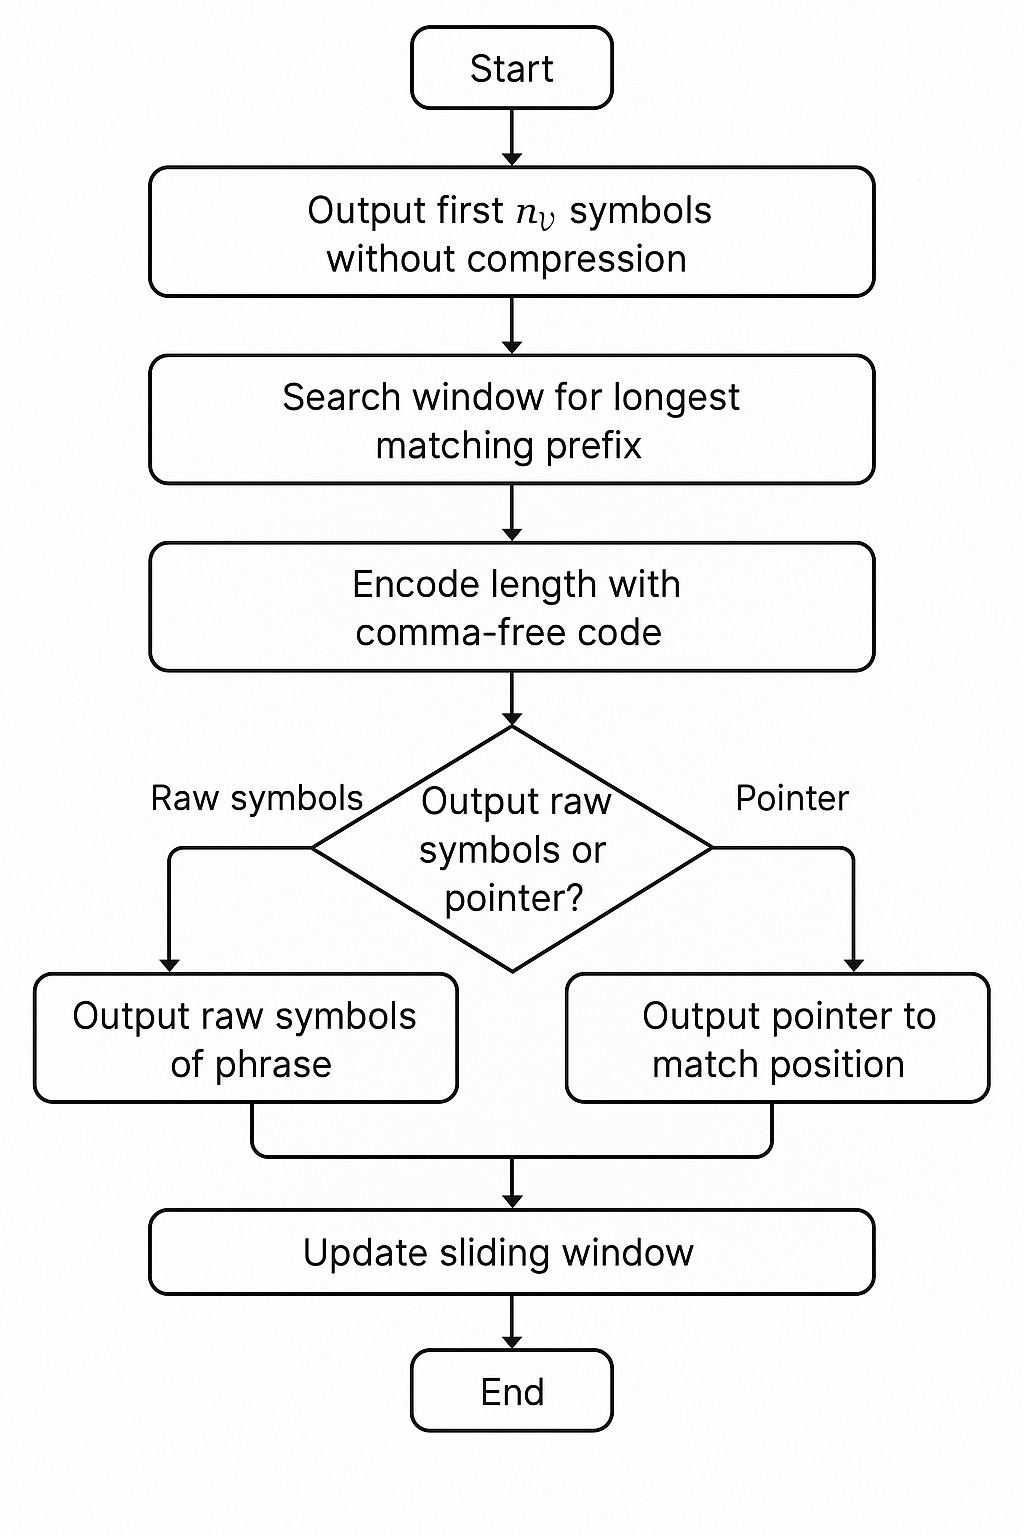

In [ ]:
import numpy as np
import math

In [ ]:
# BitBuffer class for managing bit-level read/write operations
class BitBuffer:
    def __init__(self):
        self.bits = []
        self.pos = 0  # read pointer

    def append_bits(self, bits):
        self.bits.extend(bits)

    def append_int(self, x, num_bits):
        # Append integer 'x' using 'num_bits' bits in big-endian
        for i in range(num_bits - 1, -1, -1):
            self.bits.append((x >> i) & 1)

    def append_raw(self, seq):
        # Encode a sequence of symbols as raw binary values
        for symbol in seq:
            self.append_int(int(symbol), log2_alphabet)

    def read_bit(self):
        b = self.bits[self.pos]
        self.pos += 1
        return b

    def read_bits(self, n):
        bs = self.bits[self.pos:self.pos + n]
        self.pos += n
        return bs

    def read_int(self, num_bits):
        # Read integer from bitstream
        bs = self.read_bits(num_bits)
        val = 0
        for b in bs:
            val = (val << 1) | b
        return val

    def read_raw(self, num_symbols):
        # Read a sequence of raw symbols
        return [self.read_int(log2_alphabet) for _ in range(num_symbols)]

    def bit_length(self):
        return len(self.bits)

# Comma-free encoding: unary prefix + binary body of the number
def comma_free_encode(L):
    bL = bin(L)[2:]  # binary string without '0b'
    k = len(bL)
    prefix = [0] * (k - 1) + [1]  # unary prefix (k-1 zeros followed by a one)
    body = [int(bit) for bit in bL]  # binary body
    return prefix + body

# Decode the comma-free encoded length
def comma_free_decode(buf: BitBuffer):
    z = 0
    while True:
        bit = buf.read_bit()
        if bit == 1:
            break
        z += 1
    k = z + 1  # number of bits in the body
    body = buf.read_bits(k)
    L = 0
    for bit in body:
        L = (L << 1) | bit
    return L

# LZ77 encoder using sliding window of size 'n_w'
def lz77_encode(seq, n_w):
    i = n_w  # start after initial window
    out = BitBuffer()
    out.append_raw(seq[:n_w])  # store raw window at start
    window = list(seq[:n_w])
    position_bits = math.ceil(math.log2(n_w)) if n_w > 1 else 1

    while i < len(seq):
        max_L, best_pos = 1, 0
        # Search for longest match in the window
        for pos in range(len(window)):
            L = 0
            while L < len(window) - pos and i + L < len(seq) and window[pos + L] == seq[i + L]:
                L += 1
            if L > max_L:
                max_L, best_pos = L, pos

        out.append_bits(comma_free_encode(max_L))

        # Store raw or reference depending on bit savings
        if max_L * log2_alphabet < position_bits:
            out.append_raw(seq[i:i + max_L])
        else:
            out.append_int(best_pos, num_bits=position_bits)

        phrase = list(seq[i:i + max_L])
        window = (window + phrase)[-n_w:]  # slide window
        i += max_L

    return out

# LZ77 decoder to reconstruct the original sequence
def lz77_decode(buf: BitBuffer, n_w, total_length):
    seq = buf.read_raw(n_w)  # read initial window
    window = list(seq)
    position_bits = math.ceil(math.log2(n_w)) if n_w > 1 else 1

    while len(seq) < total_length:
        L = comma_free_decode(buf)

        # Decide between raw or reference
        if L * log2_alphabet < position_bits:
            phrase = buf.read_raw(L)
        else:
            pos = buf.read_int(position_bits)
            phrase = window[pos:pos + L]
            # Handle wraparound for incomplete phrases
            if len(phrase) < L:
                phrase += window[:(pos + L) % n_w]
                phrase = phrase[:L]

        seq.extend(phrase)
        window = (window + phrase)[-n_w:]

    return np.array(seq, dtype=np.uint8)


## Simple singular test setup

In [ ]:
A = 16                           # Alphabet size
log2_alphabet = int(math.log2(A))  # Bits per symbol
n_w = 64                         # Sliding window size
N = 300000                          # Sequence length

# Generate random input sequence
seq = np.random.randint(0, A, size=N, dtype=np.uint8)

# Compress and decompress
encoded = lz77_encode(seq, n_w)
decoded = lz77_decode(encoded, n_w, N)

print(seq)
print(decoded)

# Verify correctness and print compression efficiency
assert np.array_equal(decoded, seq), "Decoded sequence does NOT match original!"
compression_rate = encoded.bit_length() / N
print(f"Test passed! Compression rate = {compression_rate:.3f} bits/symbol")
print(f"Theoratical entropy: {log2_alphabet}")

[ 3 10 10 ... 13 15  6]
[ 3 10 10 ... 13 15  6]
Test passed! Compression rate = 5.584 bits/symbol
Theoratical entropy: 4


# Generate Synthetic Test Sequences

In [ ]:
def iid_uniform(N, A=256):
    return np.random.randint(0, A, size=N, dtype=np.uint8)

def markov_chain(N, P, init_dist):
    seq = np.empty(N, dtype=np.uint8)
    seq[0] = np.random.choice(len(init_dist), p=init_dist)
    for i in range(1, N):
        seq[i] = np.random.choice(P.shape[1], p=P[seq[i-1]])
    return seq


# Run Experiments

In [ ]:
A = 16                            # Fixed alphabet size
log2_alphabet = int(math.log2(A))
n_w = 64                          # Fixed window size
Ns = [2**x for x in range(6,22)]

In [ ]:
import numpy as np
import time
import math
import matplotlib.pyplot as plt

results = []

for N in Ns:
    seq = np.random.randint(0, A, size=N, dtype=np.uint8)

    # Compress
    start_enc = time.time()
    encoded = lz77_encode(seq, n_w)
    end_enc = time.time()

    # Decompress
    start_dec = time.time()
    decoded = lz77_decode(encoded, n_w, N)
    end_dec = time.time()

    # Validate
    assert np.array_equal(decoded, seq), f"Decoded != Original for N={N}"

    # Record metrics
    compression_rate = encoded.bit_length() / N
    compression_ratio = (N * log2_alphabet) / encoded.bit_length()
    compression_time = end_enc - start_enc
    decompression_time = end_dec - start_dec

    results.append({
        "N": N,
        "rate": compression_rate,
        "ratio": compression_ratio,
        "enc_time": compression_time,
        "dec_time": decompression_time
    })

# Display results for plotting
import pandas as pd
df = pd.DataFrame(results)


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-28-9a8a32e46b37>", line 13, in <cell line: 0>
    encoded = lz77_encode(seq, n_w)
              ^^^^^^^^^^^^^^^^^^^^^
  File "<ipython-input-11-f34806d030f5>", line None, in lz77_encode
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 2099, in showtraceback
    stb = value._render_traceback_()
          ^^^^^^^^^^^^^^^^^^^^^^^^
AttributeError: 'KeyboardInterrupt' object has no attribute '_render_traceback_'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/ultratb.py", line 1101, in get_records
    

In [ ]:
df.to_csv("results.csv")

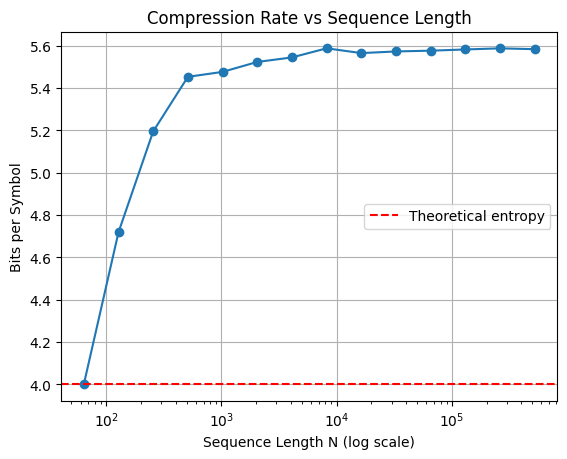

In [ ]:
plt.plot(df["N"], df["rate"], marker="o")
plt.axhline(y=log2_alphabet, color='r', linestyle='--', label='Theoretical entropy')
plt.xscale('log')
plt.xlabel("Sequence Length N (log scale)")
plt.ylabel("Bits per Symbol")
plt.title("Compression Rate vs Sequence Length")
plt.legend()
plt.grid(True)
plt.show()
